In [1]:
from google.colab import files
uploaded = files.upload()

Saving airline.csv to airline.csv


In [2]:
import pandas as pd
df = pd.read_csv("airline.csv")
df.head()

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,10856,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Edithe Leggis,On Time
1,43872,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Elwood Catt,On Time
2,42633,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Darby Felgate,On Time
3,78493,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,9/16/2022,YND,Dominica Pyle,Delayed
4,82072,Bay,Pencost,Male,21,China,Gillespie Field,US,United States,NAM,North America,2/25/2022,SEE,Bay Pencost,On Time


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df['Departure Date'] = pd.to_datetime(df['Departure Date'])

df['Year'] = df['Departure Date'].dt.year
df['Month'] = df['Departure Date'].dt.month
df['Day'] = df['Departure Date'].dt.day
df['DayOfWeek'] = df['Departure Date'].dt.day_name()

In [5]:
df.isnull().sum()

,0
Passenger ID,0
First Name,0
Last Name,0
Gender,0
Age,0
Nationality,0
Airport Name,0
Airport Country Code,0
Country Name,0
Airport Continent,0


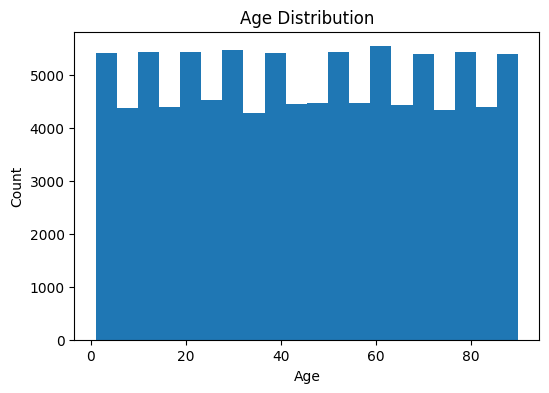

In [6]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

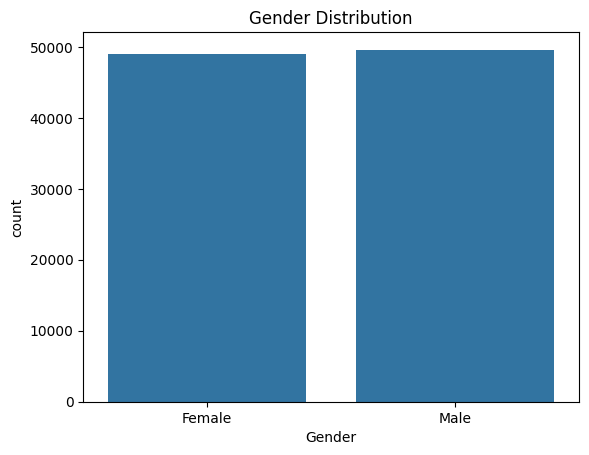

In [7]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

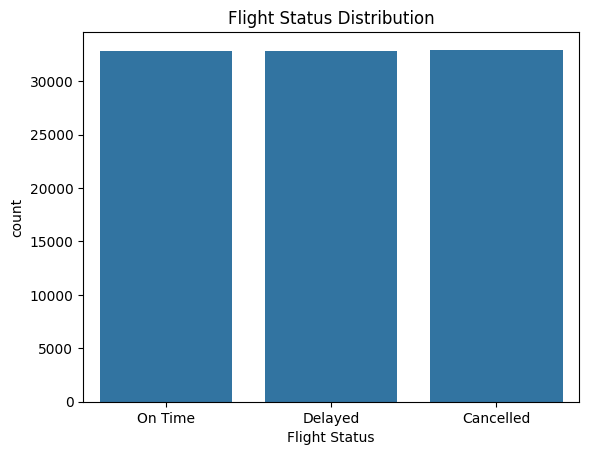

In [8]:
sns.countplot(x='Flight Status', data=df)
plt.title("Flight Status Distribution")
plt.show()

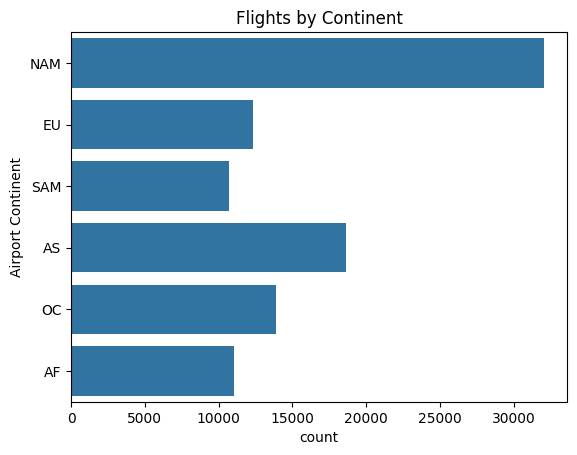

In [9]:
sns.countplot(y='Airport Continent', data=df)
plt.title("Flights by Continent")
plt.show()

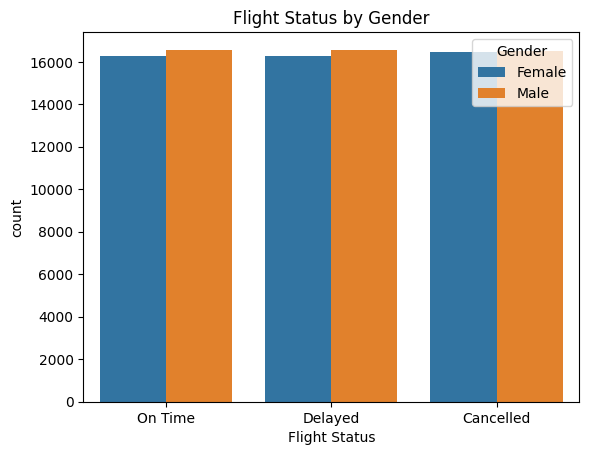

In [10]:
sns.countplot(x='Flight Status', hue='Gender', data=df)
plt.title("Flight Status by Gender")
plt.show()

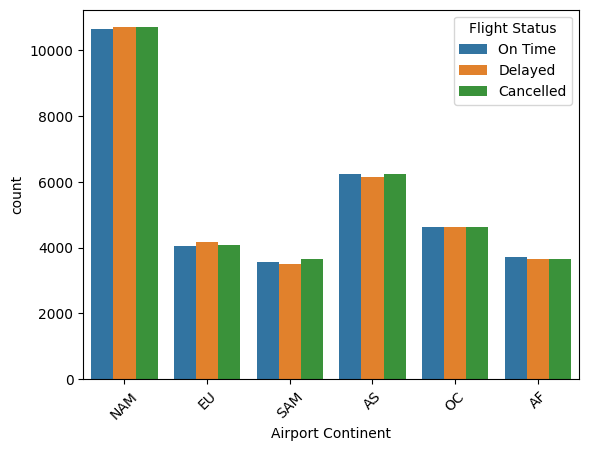

In [11]:
sns.countplot(x='Airport Continent', hue='Flight Status', data=df)
plt.xticks(rotation=45)
plt.show()

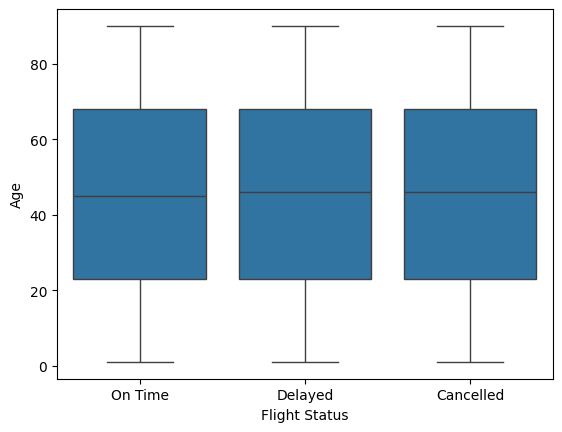

In [12]:
sns.boxplot(x='Flight Status', y='Age', data=df)
plt.show()

In [14]:
df['IsDelayed'] = df['Flight Status'].apply(lambda x: 1 if x == "Delayed" else 0)

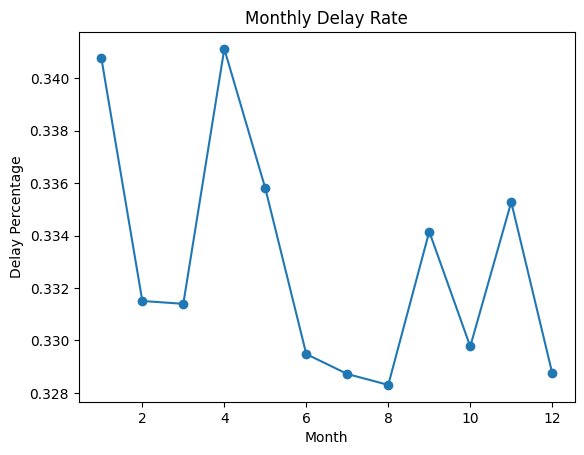

In [15]:
monthly_delay = df.groupby('Month')['IsDelayed'].mean()

monthly_delay.plot(marker='o')
plt.title("Monthly Delay Rate")
plt.ylabel("Delay Percentage")
plt.show()

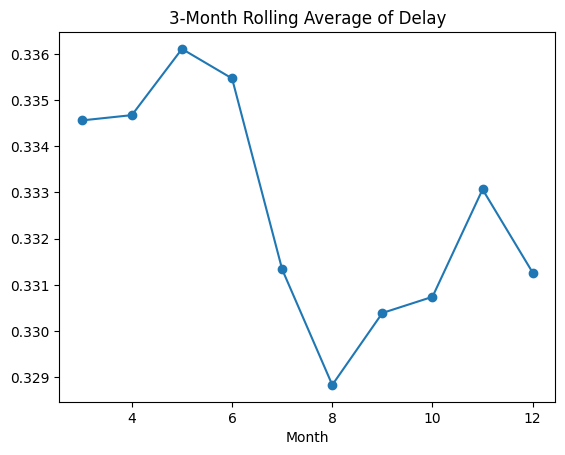

In [16]:
rolling_delay = monthly_delay.rolling(window=3).mean()

rolling_delay.plot(marker='o')
plt.title("3-Month Rolling Average of Delay")
plt.show()

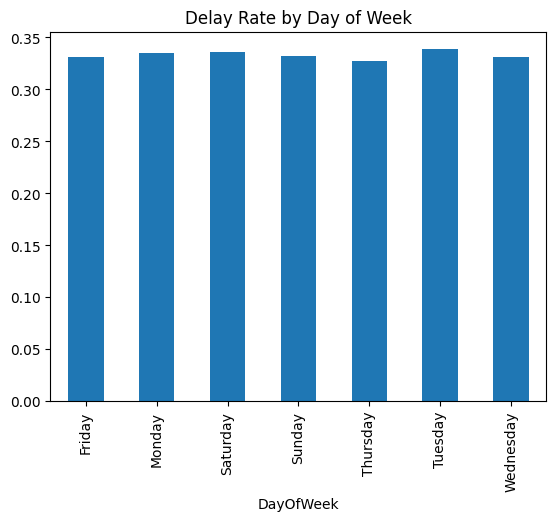

In [17]:
dow_delay = df.groupby('DayOfWeek')['IsDelayed'].mean()

dow_delay.plot(kind='bar')
plt.title("Delay Rate by Day of Week")
plt.show()

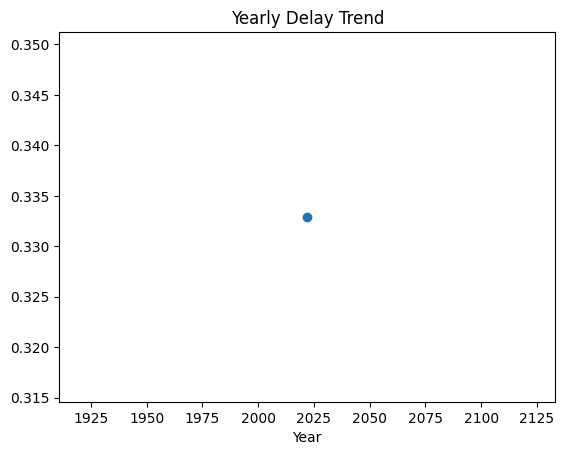

In [18]:
yearly_delay = df.groupby('Year')['IsDelayed'].mean()

yearly_delay.plot(marker='o')
plt.title("Yearly Delay Trend")
plt.show()

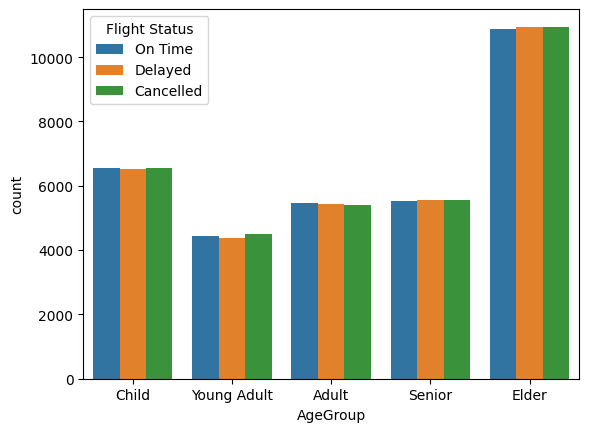

In [19]:
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0,18,30,45,60,100],
                        labels=['Child','Young Adult','Adult','Senior','Elder'])

sns.countplot(x='AgeGroup', hue='Flight Status', data=df)
plt.show()